In [8]:
from ase.db import connect
from ase.spacegroup import get_spacegroup

DB = connect('../../CrystDB/MP.db')
entry_id = 30  # data ID 
atoms = DB.get_atoms(id=entry_id)

# Basic info
N_symbols = atoms.get_chemical_symbols()         # List of chemical elements
G_spacegroup = get_spacegroup(atoms).no          # Space group number
sites = atoms.get_scaled_positions()             # Fractional coordinates
cell = atoms.get_cell()                          # Unit cell parameters
atom_coor = atoms.get_positions()                # Cartesian coordinates


/tmp/ipykernel_2280660/212525030.py:10: FutureWarning: `get_spacegroup` has been deprecated due to its misleading output. The returned `Spacegroup` object has symmetry operations for a standard setting regardress of the given `Atoms` object. See https://gitlab.com/ase/ase/-/issues/1534 for details. Please use `ase.spacegroup.symmetrize.check_symmetry` or `spglib` directly to get the symmetry operations for the given `Atoms` object.
  G_spacegroup = get_spacegroup(atoms).no          # Space group number


In [2]:
total = DB.count()
print(f'The MP.db contains {total} data entries.')

The MP.db contains 135258 data entries.


In [13]:
# ASE uses 1-based indexing for data entries
_id = 1

# Retrieve atomic structure of the first entry
atom = DB.get_atoms(id=_id)
print(f'The chemical formula of the first entry is: {atom.get_chemical_formula()}')

The chemical formula of the first entry is: Co3Ni


In [19]:
from Pysimxrd import generator
from ase.db import connect
import spglib

database = connect('../../CrystDB/MP_selected.db')
entry_id = 6

atoms = database.get_atoms(id=entry_id)

   
cell = (atoms.get_cell(), atoms.get_scaled_positions(), atoms.get_atomic_numbers())
spglib.get_symmetry(cell, symprec=1e-5)
print(database.count())

{'rotations': array([[[ 1,  0,  0],
         [ 0,  1,  0],
         [ 0,  0,  1]],
 
        [[-1,  0,  0],
         [ 0, -1,  0],
         [ 0,  0, -1]],
 
        [[-1,  0,  0],
         [ 0,  1,  0],
         [ 0,  0, -1]],
 
        [[ 1,  0,  0],
         [ 0, -1,  0],
         [ 0,  0,  1]],
 
        [[ 1,  0,  1],
         [ 0, -1,  0],
         [ 0,  0, -1]],
 
        [[-1,  0, -1],
         [ 0,  1,  0],
         [ 0,  0,  1]],
 
        [[-1,  0, -1],
         [ 0, -1,  0],
         [ 0,  0,  1]],
 
        [[ 1,  0,  1],
         [ 0,  1,  0],
         [ 0,  0, -1]]], dtype=int32),
 'translations': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.99999999e-08, 0.00000000e+00, 9.99999980e-01],
        [1.99999999e-08, 5.00000000e-01, 9.99999980e-01],
        [0.00000000e+00, 5.00000000e-01, 0.00000000e+00],
        [9.99999994e-09, 0.00000000e+00, 9.99999980e-01],
        [9.99999994e-09, 0.00000000e+00, 0.00000000e+00],
        [9.99999994e-09, 5.0000000

In [37]:
import spglib
from pymatgen.ext.matproj import MPRester

atom = DB.get_atoms(id=11203)

cell = (atom.get_cell(), atom.get_scaled_positions(), atom.get_atomic_numbers())

# 用 spglib 找对称性
MY_API_KEY = 'GcIoLryai7CyI96mFLmRM6V8fRH4J85i'
with MPRester(MY_API_KEY) as mpr:
    try:
        dataset = spglib.get_symmetry_dataset(cell, symprec=1e-5)
        print("Number:", dataset['number'])
        id = DB.get(11203).key_value_pairs.get('mpid')[:-4]
        data = mpr.get_summary_by_material_id(id,["symmetry.number","symmetry.symbol"])
        if data:
            spacegroup_info = data['symmetry']
            sg_number = spacegroup_info.get("number")
            sg_symbol = spacegroup_info.get("symbol")
        print(f"Space group number: {sg_number}, Symbol: {sg_symbol}")
    except Exception as e:
                    # 捕获 spglib 可能抛出的错误（针对不合理的结构）
                    # print(f"ID {row.id} 的结构处理失败: {e}")
        print(e)

# print(get_spacegroup(atom).no)
# print("International:", dataset['international'])
# print("Number:", dataset['number'])
# print("Symmetry operations:", dataset['rotations'])

/tmp/ipykernel_3446185/3456295850.py:13: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  print("Number:", dataset['number'])
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.


Number: 1
Space group number: 43, Symbol: Fdd2


In [6]:
from tqdm import tqdm
import spglib

total_processed = 0

for row in tqdm(DB.select(), total=len(DB)):
    total_processed += 1
    
    try:
        # 获取原始数据
        atom = row.toatoms()

        id = row.key_value_pairs.get('mpid')[:-4]
        # data = mpr.get_summary_by_material_id(id,["symmetry.number","symmetry.symbol"])
        # if data:
        #     spacegroup_info = data['symmetry']
        #     sg_number = spacegroup_info.get("number")
        #     sg_symbol = spacegroup_info.get("symbol")

        # if sg_number is None:
        #     continue
        # sg_number = data[id]['number']
        # cell = (atom.get_cell(), atom.get_scaled_positions(), atom.get_atomic_numbers())
        spg_info = get_spacegroup(atoms, symprec=1e-5)
        found_spg = spg_info.no # 实际分析出的空间群编号

        # # 检查对称性差异/不对称
        # if int(sg_number) != found_spg:
        #     rejected_discrepancy += 1
        #     continue # 排除此结构

    except Exception as e:
        rejected_spglib_error += 1
        continue

  0%|          | 0/135258 [00:00<?, ?it/s]/tmp/ipykernel_1613270/3112338637.py:24: FutureWarning: `get_spacegroup` has been deprecated due to its misleading output. The returned `Spacegroup` object has symmetry operations for a standard setting regardress of the given `Atoms` object. See https://gitlab.com/ase/ase/-/issues/1534 for details. Please use `ase.spacegroup.symmetrize.check_symmetry` or `spglib` directly to get the symmetry operations for the given `Atoms` object.
  spg_info = get_spacegroup(atoms, symprec=1e-5)
100%|██████████| 135258/135258 [03:38<00:00, 619.24it/s]


In [27]:
from tqdm import tqdm
from pymatgen.ext.matproj import MPRester

MY_API_KEY = 'GcIoLryai7CyI96mFLmRM6V8fRH4J85i'
with MPRester(MY_API_KEY) as mpr:
    data = mpr.summary_search(material_ids='mp-1234,mp-5678')
    # print(data[1])  # 输出空间群编号
    for doc in data:
        print(doc['symmetry'])

{'crystal_system': 'Cubic', 'symbol': 'Fd-3m', 'number': 227, 'point_group': 'm-3m', 'symprec': 0.1, 'angle_tolerance': 5.0, 'version': '2.5.0'}
{'crystal_system': 'Hexagonal', 'symbol': 'P6/mmm', 'number': 191, 'point_group': '6/mmm', 'symprec': 0.1, 'angle_tolerance': 5.0, 'version': '2.5.0'}


In [139]:
from tqdm import tqdm
from pymatgen.ext.matproj import MPRester

MY_API_KEY = 'GcIoLryai7CyI96mFLmRM6V8fRH4J85i'
with MPRester(MY_API_KEY) as mpr:
    for row in tqdm(DB.select(), total=len(DB)):
        atoms = row.toatoms()
        print(get_spacegroup(atoms).no)
        id = row.key_value_pairs.get('mpid')[:-4]
        data = mpr.get_summary_by_material_id(id,["symmetry.number","symmetry.symbol"])
        if data:
                # 返回的数据是一个列表，我们取第一个元素
            spacegroup_info = data['symmetry']
                
            sg_number = spacegroup_info.get("number")
            sg_symbol = spacegroup_info.get("symbol")
                
            print(f"材料ID '{id}' 在 Materials Project 数据库中的信息如下：")
            print(f"  - 空间群编号 (Space Group Number): {sg_number}")
            print(f"  - 空间群符号 (Symbol): {sg_symbol}")
                
        else:
            print(f"未能找到材料ID为 '{id}' 的数据。")


  0%|          | 0/135258 [00:00<?, ?it/s]/tmp/ipykernel_335923/2767089283.py:8: FutureWarning: `get_spacegroup` has been deprecated due to its misleading output. The returned `Spacegroup` object has symmetry operations for a standard setting regardress of the given `Atoms` object. See https://gitlab.com/ase/ase/-/issues/1534 for details. Please use `ase.spacegroup.symmetrize.check_symmetry` or `spglib` directly to get the symmetry operations for the given `Atoms` object.
  print(get_spacegroup(atoms).no)


47


  0%|          | 1/135258 [00:01<61:41:58,  1.64s/it]

材料ID 'mp-1008349' 在 Materials Project 数据库中的信息如下：
  - 空间群编号 (Space Group Number): 221
  - 空间群符号 (Symbol): Pm-3m
26


  0%|          | 2/135258 [00:02<42:33:29,  1.13s/it]

...

材料ID 'mp-1007819' 在 Materials Project 数据库中的信息如下：
  - 空间群编号 (Space Group Number): 221
  - 空间群符号 (Symbol): Pm-3m
221


  0%|          | 14/135258 [00:12<30:38:01,  1.23it/s]

材料ID 'mp-1001844' 在 Materials Project 数据库中的信息如下：
  - 空间群编号 (Space Group Number): 221
  - 空间群符号 (Symbol): Pm-3m
221


  0%|          | 14/135258 [00:13<35:00:00,  1.07it/s]


KeyboardInterrupt: 

In [30]:
import pickle

with open('api_results_cache.pkl', 'rb') as file:  # 'rb' 表示以二进制读模式打开文件
    data = pickle.load(file)

# 打印读取的数据
print(data['mp-1000']['number'])

225


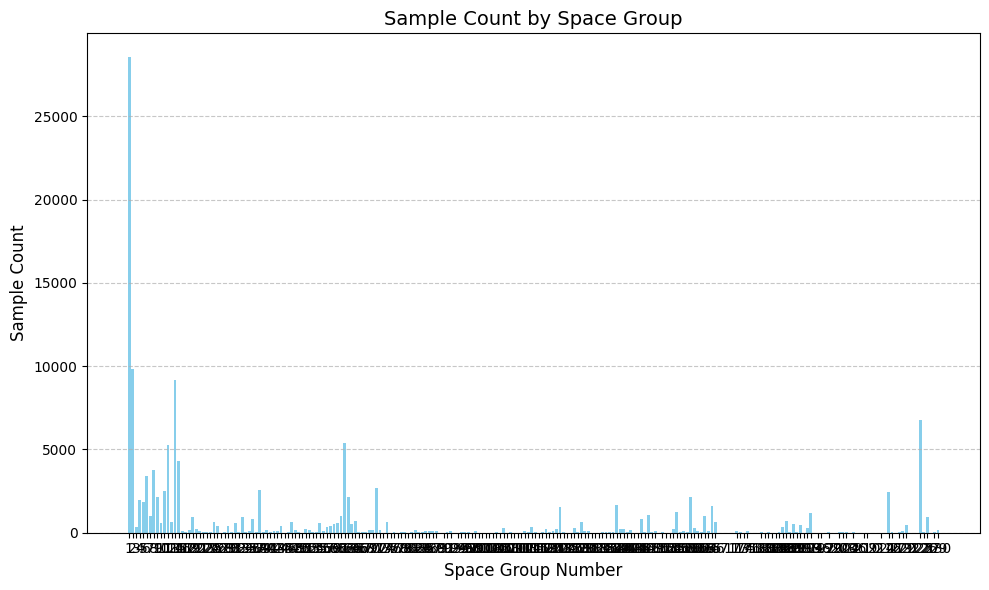

In [38]:
from collections import Counter


spg_counts = Counter(spg_list)

# 按样本数量排序
sorted_spg_counts = sorted(spg_counts.items(), key=lambda x: x[1], reverse=True)

# 分离编号和对应的样本数
spg_labels, spg_values = zip(*sorted_spg_counts)

# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.bar(spg_labels, spg_values, color='skyblue')
plt.xlabel('Space Group Number', fontsize=12)
plt.ylabel('Sample Count', fontsize=12)
plt.title('Sample Count by Space Group', fontsize=14)
plt.xticks(spg_labels, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
len(spg_list)

135258


--- 步骤 2: 转换后的 Pymatgen Structure 对象 ---
Full Formula (Na2 Mn4 O8)
Reduced Formula: NaMn2O4
abc   :   2.924086   5.921649   9.370888
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (14)
  #  SP      a         b         c
---  ----  ---  --------  --------
  0  Na    0.5  0.366548  0.949764
  1  Na    0.5  0.633452  0.449764
  2  Mn    0    0.782838  0.126304
  3  Mn    0.5  0.887734  0.852676
  4  Mn    0.5  0.112266  0.352676
  5  Mn    0    0.217162  0.626304
  6  O     0.5  0.583537  0.165475
  7  O     0    0.101406  0.819235
  8  O     0    0.898594  0.319235
  9  O     0.5  0.416463  0.665475
 10  O     0.5  0.99394   0.08272
 11  O     0    0.692401  0.919323
 12  O     0.5  0.00606   0.58272
 13  O     0    0.307599  0.419323

--- 步骤 3: 使用 Pymatgen 进行 XRD 模拟 ---
计算出的前5个衍射峰数据：
  2-Theta: 14.9608, 强度: 42.88, 晶面: (0, 1, 0)
  2-Theta: 17.7178, 强度: 100.00, 晶面: (0, 1, 1)
  2-Theta: 18.9405, 强度: 1.05, 晶面: (0, 0, 2)
  2-Theta: 24.2225, 强度: 11.46

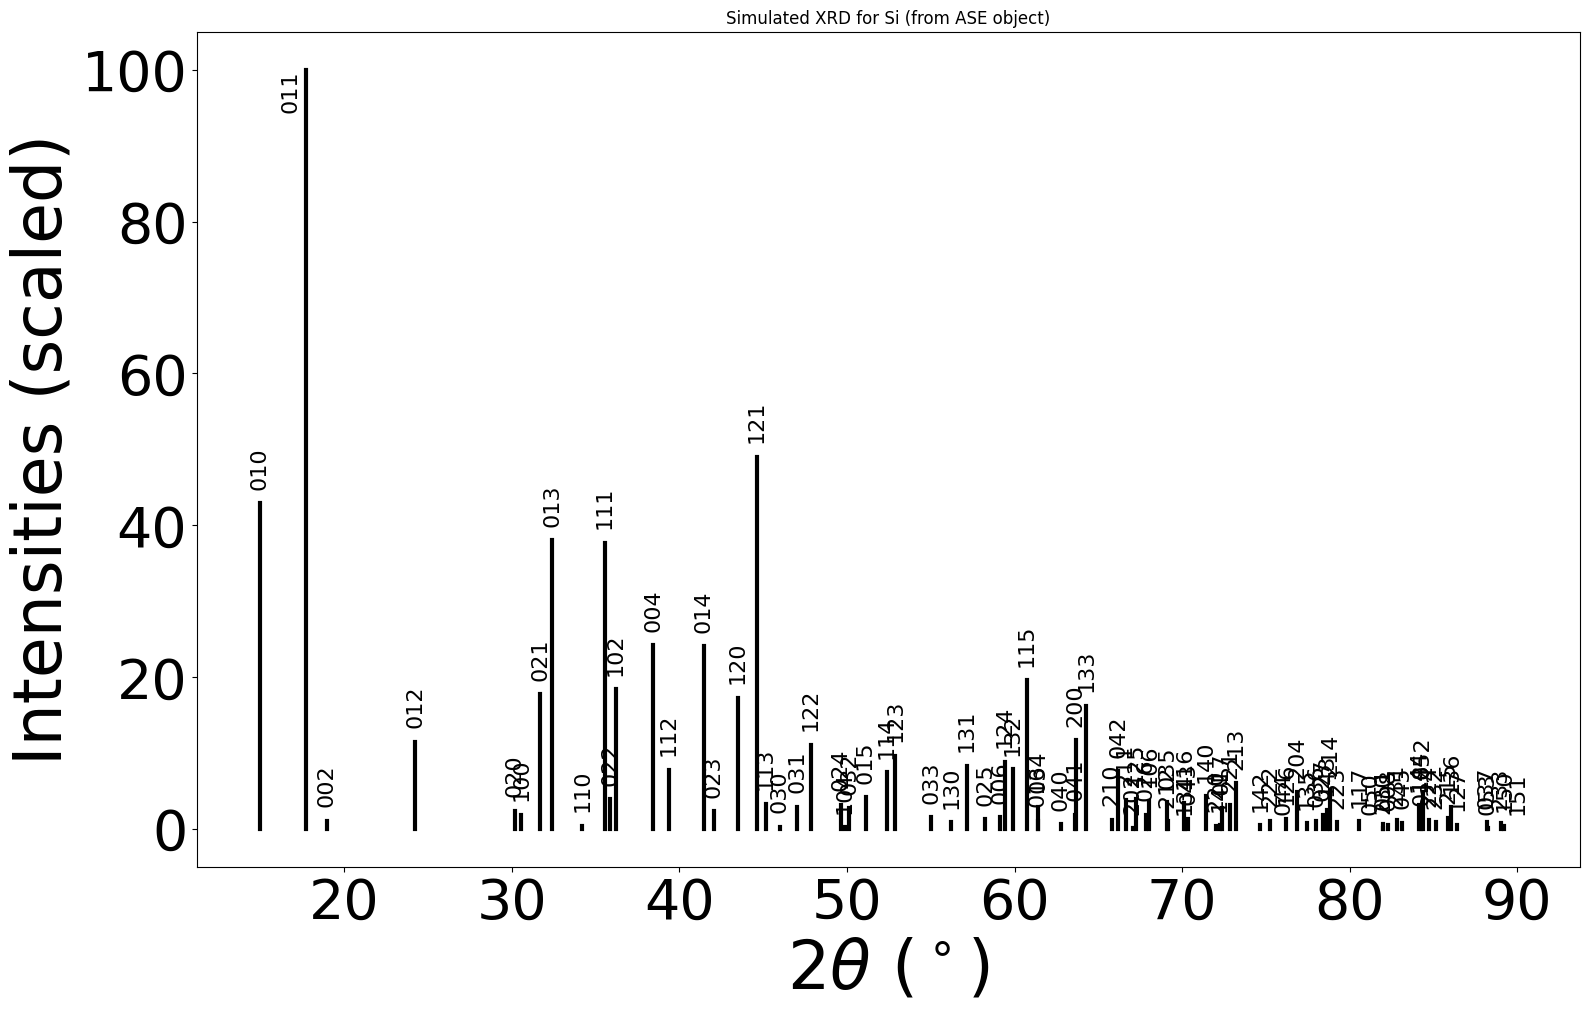

In [23]:
from ase.build import bulk
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import matplotlib.pyplot as plt

atoms_ase = DB.get_atoms(id=2)

structure_pmg = Structure.from_ase_atoms(atoms_ase)

print(structure_pmg)

# 初始化XRD计算器，指定X射线波长为铜靶K-alpha
calculator = XRDCalculator(wavelength='CuKa')

pattern = calculator.get_pattern(structure_pmg)

# 打印前5个衍射峰的数据
print("计算出的前5个衍射峰数据：")
for i in range(5):
    angle = pattern.x[i]      # 2-theta 衍射角
    intensity = pattern.y[i]  # 相对强度 (0-100)
    hkl = pattern.hkls[i][0]['hkl'] # 对应的晶面指数
    
    print(f"  2-Theta: {angle:.4f}, 强度: {intensity:.2f}, 晶面: {hkl}")

calculator.get_plot(structure_pmg)
plt.title(f"Simulated XRD for Si (from ASE object)")
plt.show()

Full Formula (Na2 Mn4 O8)
Reduced Formula: NaMn2O4
abc   :   2.924086   5.921649   9.370888
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (14)
  #  SP      a         b         c
---  ----  ---  --------  --------
  0  Na    0.5  0.366548  0.949764
  1  Na    0.5  0.633452  0.449764
  2  Mn    0    0.782838  0.126304
  3  Mn    0.5  0.887734  0.852676
  4  Mn    0.5  0.112266  0.352676
  5  Mn    0    0.217162  0.626304
  6  O     0.5  0.583537  0.165475
  7  O     0    0.101406  0.819235
  8  O     0    0.898594  0.319235
  9  O     0.5  0.416463  0.665475
 10  O     0.5  0.99394   0.08272
 11  O     0    0.692401  0.919323
 12  O     0.5  0.00606   0.58272
 13  O     0    0.307599  0.419323


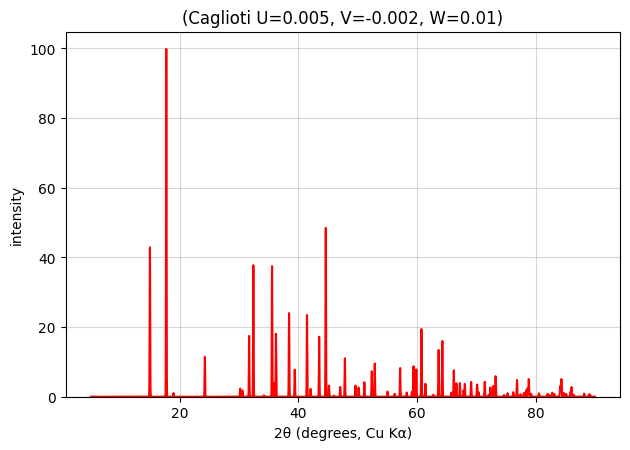

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from ase.build import bulk


atoms_ase = DB.get_atoms(id=2)


structure_pmg = Structure.from_ase_atoms(atoms_ase)
print(structure_pmg)

calculator = XRDCalculator(wavelength='CuKa')

pattern_stick = calculator.get_pattern(structure_pmg)


def smear_with_caglioti(stick_pattern, two_theta_range, resolution, U, V, W):
    """
    使用Caglioti公式对理论峰棍图进行高斯展宽。

    Args:
        stick_pattern: Pymatgen生成的Pattern对象。
        two_theta_range (tuple): 最终谱图的2-theta范围 (起始, 结束)。
        resolution (float): 谱图的分辨率 (步长)。
        U, V, W (float): Caglioti公式的参数。

    Returns:
        tuple: (x_axis, y_spectrum) - 展宽后谱图的X轴和Y轴数据。
    """
    x_axis = np.arange(two_theta_range[0], two_theta_range[1], resolution)
    y_spectrum = np.zeros_like(x_axis)

    angles_deg = stick_pattern.x
    intensities = stick_pattern.y

    angles_rad = np.deg2rad(angles_deg)

    theta_rad = angles_rad / 2
    fwhm_squared = U * np.tan(theta_rad)**2 + V * np.tan(theta_rad) + W

    fwhm_squared[fwhm_squared < 0] = 0
    fwhm_deg = np.sqrt(fwhm_squared)

    sigma = fwhm_deg / (2 * np.sqrt(2 * np.log(2)))

    for i in range(len(angles_deg)):
        angle = angles_deg[i]
        intensity = intensities[i]

        if intensity < 1e-5 or sigma[i] < 1e-5:
            continue

        peak_profile = intensity * np.exp(-((x_axis - angle)**2) / (2 * sigma[i]**2))

        y_spectrum += peak_profile
        
    return x_axis, y_spectrum



# 定义 Caglioti 参数
# U, V, W
caglioti_params = (0.005, -0.002, 0.01)

# 调用函数生成连续谱图
x_smeared, y_smeared = smear_with_caglioti(
    pattern_stick,
    two_theta_range=(5, 90),
    resolution=0.02,
    U=caglioti_params[0],
    V=caglioti_params[1],
    W=caglioti_params[2]
)


plt.plot(x_smeared, y_smeared, color='r')
plt.title(f"(Caglioti U={caglioti_params[0]}, V={caglioti_params[1]}, W={caglioti_params[2]})")
plt.xlabel(r"2θ (degrees, Cu Kα)")
plt.ylabel("intensity")
plt.ylim(bottom=0)
plt.grid(alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [1]:
import os
from ase.db import connect
import spglib
import numpy as np


files = os.listdir('./generation/Generated/XRDs_from_ASE')
print(len(files))
for file in files:
    data = np.load('./generation/Generated/XRDs_from_ASE/'+file, allow_pickle=True)
    print(data)
    break

745129
{'features': array([0, 0, 0, ..., 1, 1, 1]), 'labels7': 0, 'labels230': 0}


找到了 745129 个文件。
正在读取并绘制文件: ID_mp-767771_0_1.npy


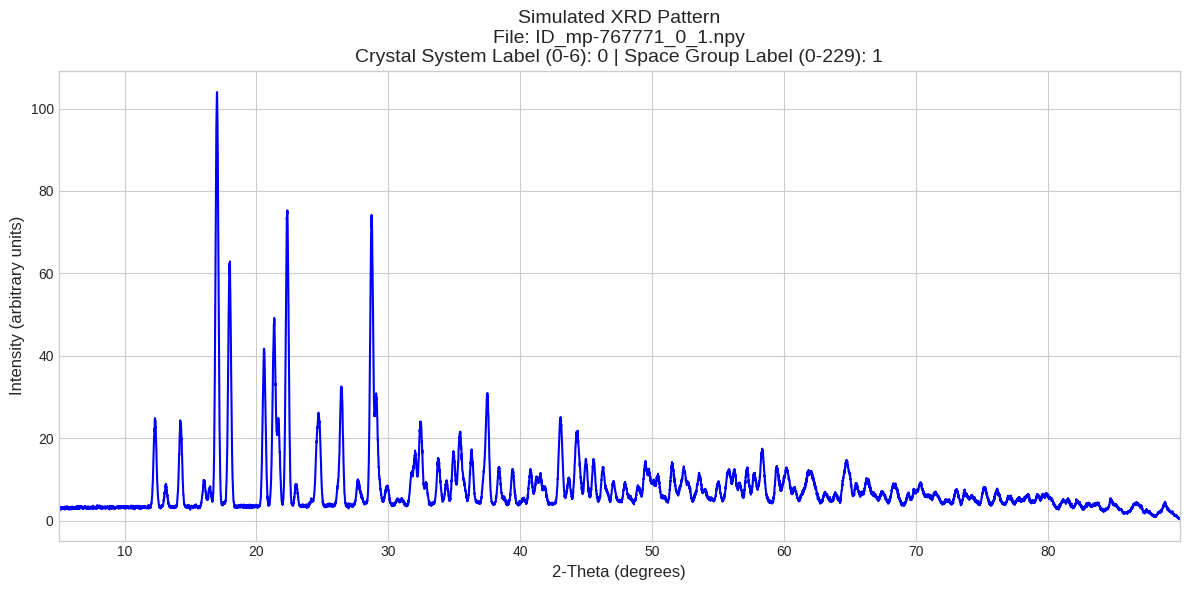

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random

def read_and_plot_one_xrd(data_directory):
    """
    在指定目录中查找.npy文件，随机选取一个加载，并将其中的XRD数据绘制成图。

    参数:
    data_directory (str): 存放.npy数据文件的目录路径。
    """

    search_path = os.path.join(data_directory, '**', '*.npy')
    file_list = glob.glob(search_path, recursive=True)

    if not file_list:
        print(f"错误：在目录 '{data_directory}' 中没有找到任何.npy文件。")
        print("请确保路径正确，并且该目录下存放了生成的数据。")
        return

    print(f"找到了 {len(file_list)} 个文件。")

    # 2. 随机选取一个文件
    random_file_path = random.choice(file_list)
    print(f"正在读取并绘制文件: {os.path.basename(random_file_path)}")

    try:
        data_dict = np.load(random_file_path, allow_pickle=True).item()

        y_intensity = data_dict['features']
        crystal_system_label = data_dict['labels7']
        space_group_label = data_dict['labels230']

        # 4. 重建X轴 (2-Theta角度)
        # 根据生成脚本的设置：从5度到90度，步长0.01度
        x_step = 0.01
        start_angle = 5.0
        end_angle = start_angle + len(y_intensity) * x_step
        x_angle = np.arange(start_angle, end_angle, x_step)

        # 确保X和Y轴的数据点数量一致
        if len(x_angle) != len(y_intensity):
            print(f"警告：X轴和Y轴的数据点数量不匹配。X: {len(x_angle)}, Y: {len(y_intensity)}")
            # 调整X轴以匹配Y轴的长度
            x_angle = np.linspace(start_angle, end_angle, len(y_intensity), endpoint=False)


        # 5. 使用matplotlib绘图
        plt.style.use('seaborn-v0_8-whitegrid') # 使用一个好看的绘图风格
        fig, ax = plt.subplots(figsize=(12, 6)) # 创建一个稍大的图像

        ax.plot(x_angle, y_intensity, color='blue', linewidth=1.5)

        # 设置图表标题和坐标轴标签
        title_text = (
            f"Simulated XRD Pattern\n"
            f"File: {os.path.basename(random_file_path)}\n"
            f"Crystal System Label (0-6): {crystal_system_label} | "
            f"Space Group Label (0-229): {space_group_label}"
        )
        ax.set_title(title_text, fontsize=14)
        ax.set_xlabel("2-Theta (degrees)", fontsize=12)
        ax.set_ylabel("Intensity (arbitrary units)", fontsize=12)

        # 设置坐标轴范围和刻度
        ax.set_xlim(start_angle, end_angle - x_step)
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=10)

        # 显示图像
        plt.tight_layout() # 自动调整布局
        plt.show()

    except Exception as e:
        print(f"处理文件 {random_file_path} 时发生错误: {e}")


DATA_DIRECTORY = './generation/Generated/XRDs_from_ASE'

read_and_plot_one_xrd(DATA_DIRECTORY)

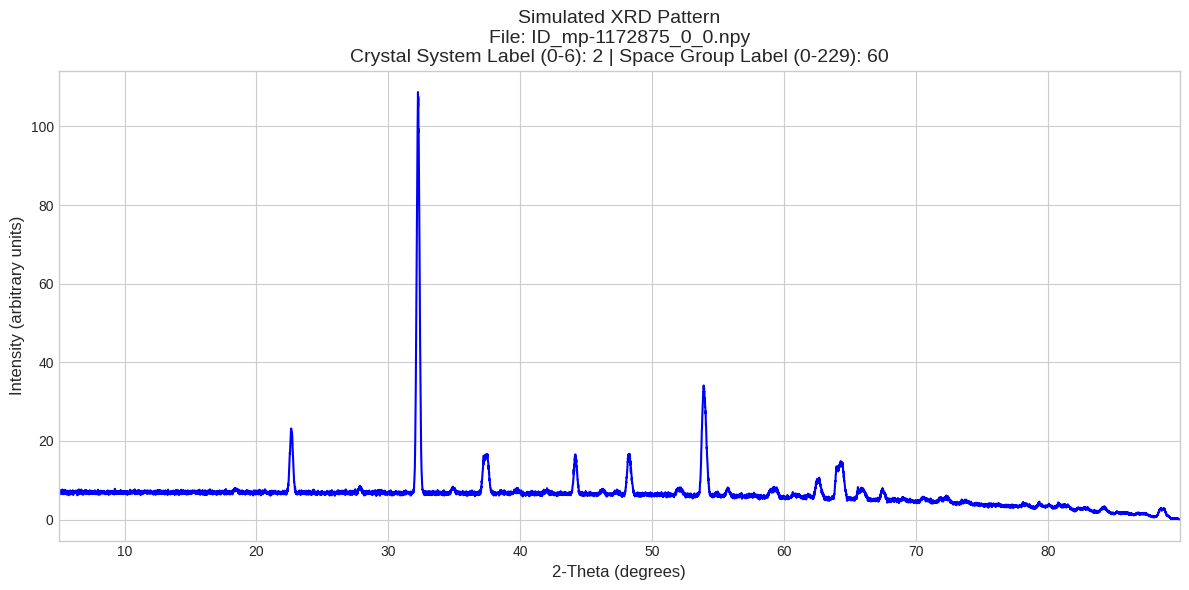

In [18]:
random_file_path = './generation/Generated/XRDs_from_ASE/ID_mp-1172875_0_0.npy'
data_dict = np.load(random_file_path, allow_pickle=True).item()

y_intensity = data_dict['features']
crystal_system_label = data_dict['labels7']
space_group_label = data_dict['labels230']

x_step = 0.01
start_angle = 5.0
end_angle = start_angle + len(y_intensity) * x_step
x_angle = np.arange(start_angle, end_angle, x_step)

if len(x_angle) != len(y_intensity):
    print(f"警告：X轴和Y轴的数据点数量不匹配。X: {len(x_angle)}, Y: {len(y_intensity)}")
    # 调整X轴以匹配Y轴的长度
    x_angle = np.linspace(start_angle, end_angle, len(y_intensity), endpoint=False)

plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(12, 6)) 

ax.plot(x_angle, y_intensity, color='blue', linewidth=1.5)

title_text = (
    f"Simulated XRD Pattern\n"
    f"File: {os.path.basename(random_file_path)}\n"
    f"Crystal System Label (0-6): {crystal_system_label} | "
    f"Space Group Label (0-229): {space_group_label}"
)
ax.set_title(title_text, fontsize=14)
ax.set_xlabel("2-Theta (degrees)", fontsize=12)
ax.set_ylabel("Intensity (arbitrary units)", fontsize=12)

ax.set_xlim(start_angle, end_angle - x_step)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout() 
plt.show()

In [1]:
import numpy as np
data = np.load('simulated_xrd.npz')
data

NpzFile 'simulated_xrd.npz' with keys: names, features, labels7, labels230

In [2]:
names = data['names']
features = data['features']
labels7 = data['labels7']
labels230 = data['labels230']

KeyboardInterrupt: 

In [13]:
features.shape

(745129, 8500)

In [14]:
from utils.SimDataset import SimDataset

dataset = SimDataset('simulated_xrd.npz')